# __Predicting Airbnb Listing Prices in Melbourne, Australia__
---

**Goal:** Predict listed prices of Airbnb properties in Melbourne based on various Airbnb characteristics and regression models 

**Problem**: Currently there is no convenient way for a new Airbnb host to decide the price of his or her listing. New hosts must often rely on the price of neighbouting listings when deciding on the price of their own listing. 

The project aims at predicting Airbnb listing prices for Melbourne based on the characteristics of listed properties to help hosts decide reasonable price. A Predictive Price Modelling tool whereby a new host can enter all the relevant details such as location of the listing, listing properties, available amenities etc and the Machine Learning Model will suggest the Price for the listing. We will train and make comparisons between different methods. 

## 1. Problem Description and Initial Data Analysis

### Forecasting Problem

This project aims to predict the **listed nightly price** of Airbnb properties in **Melbourne, Australia** using a supervised **regression** approach. The key challenge for new hosts is that pricing decisions are often made by manually comparing nearby listings, which can be inconsistent and time-consuming. By learning relationships between a listing’s attributes (e.g., **location**, **room/property type**, **capacity**, **amenities**, **host characteristics**, and **review signals**) and its listed price, the model can provide a **data-driven suggested price** for new or updated listings.

The predicted output is a **continuous numeric value** (`price`). The model will be trained on a **labelled dataset** containing historical listing characteristics and corresponding prices. The objective is to generalise well to **unseen listings** so the model can be used as a practical price suggestion tool.

---

### Evaluation Criteria

This project evaluates model accuracy using **Mean Absolute Error (MAE)**, which measures the average absolute difference between predicted and actual prices:

$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$

- **Why MAE is appropriate for Airbnb price prediction**
  - **Easy to interpret:** MAE expresses error in **dollars**, making results intuitive for stakeholders and users.  
  - **Robust to outliers (compared to MSE/RMSE):** A small number of unusually expensive listings is less likely to dominate the metric.  
  - **Balanced error treatment:** MAE reflects typical absolute error without heavily penalising rare extreme mistakes.

- **Limitations of MAE**
  - **Equal weighting of all errors:** A \$50 error on a premium listing is treated the same as a \$50 error on a budget listing, even though business impact may differ.  
  - **No relative context:** MAE does not indicate whether error is large **relative** to the true price (e.g., \$30 may be small for luxury, large for budget).


In [2]:
# import libraries 
import pandas as pd 
import numpy as np 

import seaborn as sns 
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure 

In [32]:
# Load dataset 
df_train = pd.read_csv('dataset/train.csv') 
df_test = pd.read_csv('dataset/test.csv') 

In [33]:
# Display basic information about the datasets
df_train.info()
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 61 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   ID                                            7000 non-null   int64  
 1   source                                        7000 non-null   object 
 2   name                                          6999 non-null   object 
 3   description                                   6936 non-null   object 
 4   neighborhood_overview                         5209 non-null   object 
 5   host_name                                     7000 non-null   object 
 6   host_since                                    7000 non-null   object 
 7   host_location                                 5644 non-null   object 
 8   host_about                                    4720 non-null   object 
 9   host_response_time                            7000 non-null   o

****Types of Variables / Features****

The dataset contains a mixture of **numerical**, **categorical**, **text**, and **date/time** variables describing listing characteristics, host attributes, availability constraints, and review signals. For modeling, variables are grouped into the following categories.

****Categorise Variables****

| Variable Type | Number of Features | Feature Names |
|:-------------:|:-----------------:|:--------------|
| Numerical     | 37 | host_response_rate<br>host_acceptance_rate<br>host_listings_count<br>latitude<br>longitude<br>accommodates<br>bathrooms<br>bedrooms<br>beds<br>minimum_nights<br>maximum_nights<br>minimum_minimum_nights<br>maximum_minimum_nights<br>minimum_maximum_nights<br>maximum_maximum_nights<br>minimum_nights_avg_ntm<br>maximum_nights_avg_ntm<br>availability_30<br>availability_60<br>availability_90<br>availability_365<br>number_of_reviews<br>number_of_reviews_ltm<br>number_of_reviews_l30d<br>review_scores_rating<br>review_scores_accuracy<br>review_scores_cleanliness<br>review_scores_checkin<br>review_scores_communication<br>review_scores_location<br>review_scores_value<br>calculated_host_listings_count<br>calculated_host_listings_count_entire_homes<br>calculated_host_listings_count_private_rooms<br>calculated_host_listings_count_shared_rooms<br>reviews_per_month |
| Ordinal       | 2  | host_response_time<br>room_type |
| Nominal       | 7  | host_is_superhost<br>host_verifications<br>host_has_profile_pic<br>host_identity_verified<br>property_type<br>has_availability<br>instant_bookable |
| Text          | 10 | source<br>name<br>description<br>neighborhood_overview<br>host_name<br>host_location<br>host_about<br>host_neighbourhood<br>neighbourhood<br>neighbourhood_cleansed<br>amenities |
| Date          | 3  | host_since<br>first_review<br>last_review |

### Non-feature Columns

| Column | Role | Included as Feature? | Rationale |
|---|---|:---:|---|
| `ID` | Identifier | No | Unique key used to map predictions to listings; not a property characteristic |
| `price` | Target | No | Outcome variable to be predicted; analysed separately as the prediction objective (converted to numeric if required) |

> **Note**: The variables `ID` and `price` are not included in the feature table because `ID` is a unique identifier and `price` is the target variable. Although `price` may appear as text in its raw form (e.g., `$132.00`), it will be converted to a numerical type for modeling purposes.


## 2. Missing Values 

In [14]:
# Summarise missing values
def missing_summary(df, name):
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    percent = (missing / len(df)) * 100
    return pd.DataFrame({
        f'{name}_Missing': missing,
        f'{name}_Missing(%)': percent.round(2)
    })

# Generate missing value summaries
train_missing = missing_summary(df_train, "Train")
test_missing = missing_summary(df_test, "Test")

# Combine summaries
missing_df = pd.concat([train_missing, test_missing], axis=1)

# Drop rows with all missing values (feature not missing in either set)
missing_df = missing_df.dropna(how="all")

# Display
missing_df.style.set_caption("Missing Values Summary").format(precision=2)

,Train_Missing,Train_Missing(%),Test_Missing,Test_Missing(%)
host_neighbourhood,3341.00,47.73,2213.00,73.77
host_about,2280.00,32.57,1451.00,48.37
neighbourhood,1791.00,25.59,1470.00,49.00
neighborhood_overview,1791.00,25.59,1470.00,49.00
host_location,1356.00,19.37,720.00,24.00
bedrooms,358.00,5.11,82.00,2.73
room_type,134.00,1.91,41.00,1.37
neighbourhood_cleansed,108.00,1.54,42.00,1.40
beds,85.00,1.21,12.00,0.40
property_type,84.00,1.20,39.00,1.30


The dataset contains several features with missing values in both the training and test sets, with missingness concentrated in **text- and location-related fields** and a few **host/review** attributes. Overall, the **test set shows higher missing rates** for several key fields compared to the training set.

- **High missing rate (≥ 25%)**: Missingness is most pronounced in host and neighbourhood description fields.  
  - `host_neighbourhood` is missing for **47.73%** of the training set and **73.77%** of the test set (the highest missingness observed).  
  - `host_about` is missing for **32.57%** (train) and **48.37%** (test).  
  - `neighbourhood` and `neighborhood_overview` are each missing for **25.59%** (train) and **49.00%** (test).  
  These patterns suggest incomplete host profiles and/or inconsistent neighbourhood descriptions, with substantially more gaps in the test data.

- **Moderate missing rate (~5% to 25%)**:  
  - `host_location` shows moderate missingness: **19.37%** (train) vs **24.00%** (test).  
  - `bedrooms` is missing in **5.11%** of training and **2.73%** of test.  
  These fields may require careful handling as they can be informative predictors of price (e.g., bedrooms, location context).

- **Low missing rate (< 5%)**: Most remaining structured features have relatively low missingness.  
  - Several categorical fields such as `room_type` (**1.91%** train; **1.37%** test), `property_type` (**1.20%** train; **1.30%** test), and `neighbourhood_cleansed` (**1.54%** train; **1.40%** test) have minor gaps.  
  - Review sub-scores (e.g., `review_scores_cleanliness`, `review_scores_checkin`, `review_scores_value`, etc.) are **< 0.4%** missing in train but around **4.73%** missing in test, indicating a larger share of listings with incomplete review information in the test set.

- **Missingness present only in the test set (potential distribution shift)**: Some variables show **no missing values in training** but notable missingness in test, including:  
  - `host_response_time` and `host_response_rate` (**12.93%** missing in test)  
  - `review_scores_rating`, `first_review`, `last_review`, and `reviews_per_month` (**4.10%** missing in test)  
  This suggests the test set may contain a higher proportion of listings with incomplete host responsiveness and review history compared to the training data.

At this stage, missing values are reported descriptively only; strategies for handling missingness (e.g., imputation, indicators, or feature engineering) will be considered during preprocessing in later tasks.

---
## Univariate data characteristics in training set  
### Exploring target variable (`price`)

In this section, the distribution of the target variable (`price`) is examined. Airbnb prices typically show a **right-skewed** distribution due to a small number of premium listings. To improve interpretability and reduce skewness, a **logarithmic transformation** is also visualised using `log1p(price)`, which makes patterns and outliers easier to observe.

,count,mean,std,min,25%,50%,75%,max
price,7000.0,237.7,1316.73,19.0,102.0,157.0,243.0,104983.0


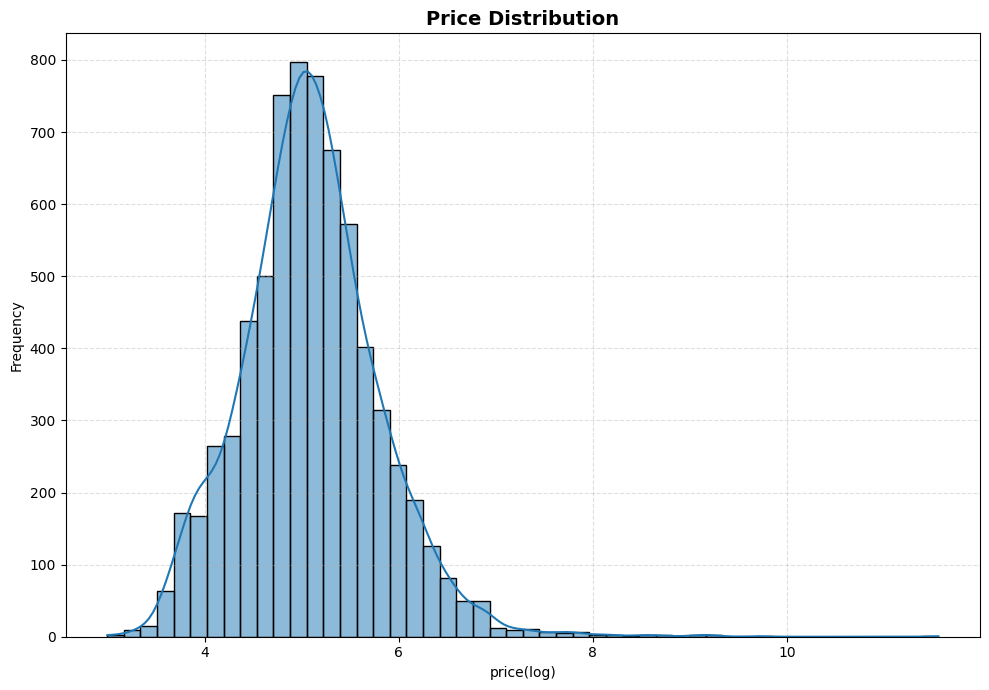

,Price (log1p),Approx. Original Price
0,4,53.60
1,5,147.41
2,6,402.43


In [26]:
# Price variable exploration

train = df_train.copy()

# 1) Convert price to numeric (handles "$132.00" or already numeric)
train["price"] = train["price"].astype(str).str.replace(r"[\$,]", "", regex=True)
train["price"] = pd.to_numeric(train["price"], errors="coerce")

# 2) Basic summary table
summary = train["price"].describe()
summary_table = pd.DataFrame(summary).T.round(2)
display(summary_table)

# 3) Log transform (safer for skew + zero values)
train["price_log"] = np.log1p(train["price"])

# 4) Plot  price distribution 

plt.figure(figsize=(10,7))
sns.histplot(train["price_log"].dropna(), bins=50, kde=True)
plt.title("Price Distribution", fontsize=14, fontweight="bold")
plt.xlabel("price(log)")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


display(price_table)


**Observation:** 
   - The target variable `price` is strongly right-skewed, with most listings concentrated in the lower-to-mid price range (median ≈ **$157**, IQR ≈ **$102–$243**) and a small number of extreme high-priced outliers (max ≈ **$104,983**), which inflates the mean (≈ **$238**). After applying `log(price)`, the distribution becomes much closer to bell-shaped, making the central trend clearer and reducing the visual impact of extreme values.

---
****How Prices Vary by Location in Melbourne****

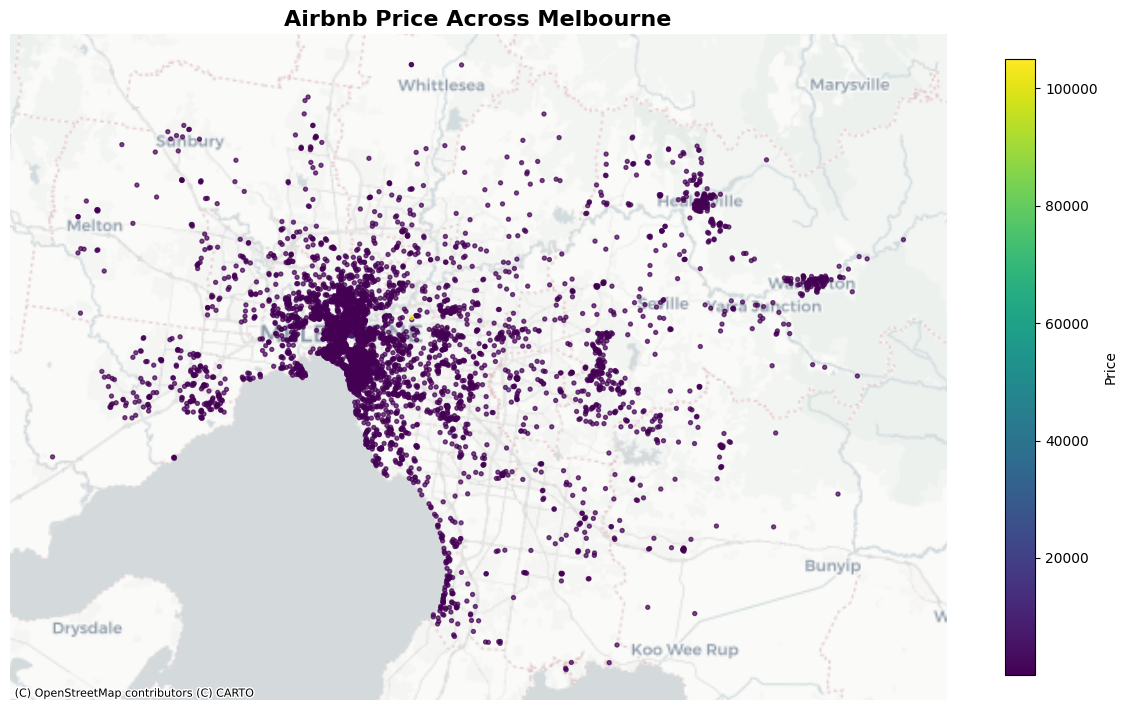

In [ ]:
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point

# --- make a clean working copy
train = df_train.copy()

# --- ensure price is numeric (handles "$132.00")
train["price"] = train["price"].astype(str).str.replace(r"[\$,]", "", regex=True)
train["price"] = pd.to_numeric(train["price"], errors="coerce")

# --- drop rows missing geo coords or price
d = train.dropna(subset=["latitude", "longitude", "price"]).copy()

# --- create GeoDataFrame in WGS84
gdf = gpd.GeoDataFrame(
    d,
    geometry=gpd.points_from_xy(d["longitude"], d["latitude"]),
    crs="EPSG:4326"
)

# --- convert to Web Mercator for basemap tiles
gdf = gdf.to_crs(epsg=3857)

# --- plot
fig, ax = plt.subplots(figsize=(12, 8))
gdf.plot(
    ax=ax,
    column="price",
    markersize=8,
    alpha=0.7,
    legend=True,
    legend_kwds={"label": "Price", "shrink": 0.8}
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

ax.set_title("Airbnb Price Across Melbourne", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [34]:
train["price"].describe()


count      7000.000000
mean        237.695857
std        1316.726117
min          19.000000
25%         102.000000
50%         157.000000
75%         243.000000
max      104983.000000
Name: price, dtype: float64

The summary statistics show that Airbnb prices are **highly right-skewed**, with a small number of extreme listings pushing the maximum to **$104,983** and inflating the standard deviation. In contrast, the *typical* listing price is much lower: the median is **$157** and the 75th percentile is **$243**, meaning most listings fall around the mid-price band.  

To make spatial patterns among **common listings** visible (rather than having the colour scale dominated by rare outliers), the map uses a **focused colour scale of $150–$300**. This highlights meaningful location-based variation where most observations lie, while still keeping all listings on the map (values outside the range simply saturate at the colour limits).

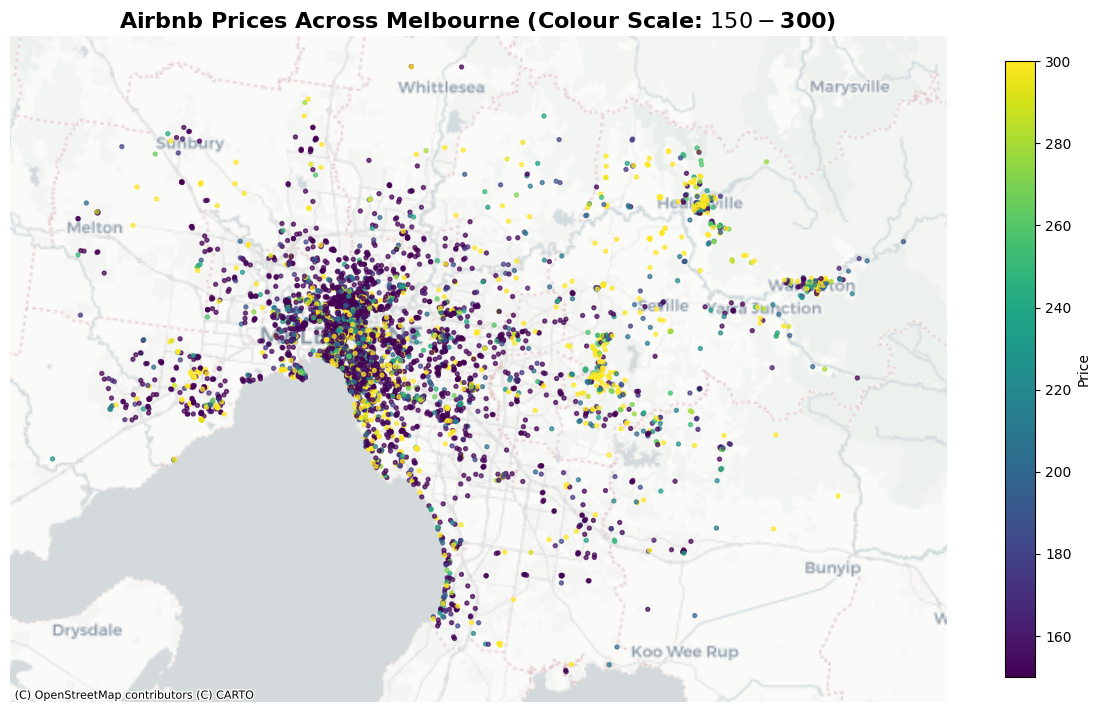

In [39]:
#Load libraries
import geopandas as gpd
import contextily as ctx

train = df_train.copy()
train["price"] = pd.to_numeric(train["price"].astype(str).str.replace(r"[\$,]", "", regex=True), errors="coerce")

d = train.dropna(subset=["latitude","longitude","price"]).copy()

gdf = gpd.GeoDataFrame(
    d, geometry=gpd.points_from_xy(d["longitude"], d["latitude"]),
    crs="EPSG:4326"
).to_crs(epsg=3857)

# ---- choose your niche range here
vmin, vmax = 150, 300   # change to 150-400 or 100-500 if you want

fig, ax = plt.subplots(figsize=(12, 8))
gdf.plot(
    ax=ax,
    column="price",
    markersize=8,
    alpha=0.7,
    legend=True,
    vmin=vmin, vmax=vmax,   # <-- KEY: zoomed colour scale
    legend_kwds={"label": f"Price", "shrink": 0.8}
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_title(f"Airbnb Prices Across Melbourne (Colour Scale: ${vmin}-${vmax})", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()


**Observation:** 
  - The map shows a high concentration of listings in Melbourne’s central, southern, and south-eastern suburbs. In contrast, the western and outer northern areas (e.g., Melton and Whittlesea) have noticeably fewer listings.